# 🤖 Machine-Learning Trading Signal with Alpaca (Paper Trading Only)

**Homework 3.** Build a simple ML trading signal on Alpaca market data,
evaluate it with a backtest, and demo it in Alpaca's **paper** environment.

> ⚠️ **This is PAPER TRADING ONLY — no real money is used.**

Pipeline: **Data → Features → PCA → ML model → Signal → Backtest → Metrics → Paper trade.**


In [1]:
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd

from src.data import get_daily_ohlcv
from src.features import build_features, FEATURE_COLUMNS
from src.model import train_signal_model
from src.backtest import run_backtest
from src.metrics import metrics_table
from src.plotting import (plot_pca_variance, plot_equity_curves,
                          plot_drawdowns, plot_signal)

TICKER = "F"         # try AAPL, MSFT, SPY, QQQ, NVDA …
MODEL  = "gradient_boosting"
THRESHOLD = 0.60
print("Config:", TICKER, MODEL, "threshold", THRESHOLD)

Config: F gradient_boosting threshold 0.6


## 1 · Data Collection — 5 years of daily OHLCV from Alpaca

In [2]:
df = get_daily_ohlcv(TICKER, years=5)
print(f"{len(df)} bars: {df.index[0].date()} -> {df.index[-1].date()}")
df.tail()

1255 bars: 2021-07-06 -> 2026-07-08


,open,high,low,close,volume
date,,,,,
2026-07-01 04:00:00,13.845,13.880,13.545,13.650,2171502.0
2026-07-02 04:00:00,13.840,13.995,13.230,13.345,1917823.0
2026-07-06 04:00:00,13.570,13.895,13.460,13.840,2472495.0
2026-07-07 04:00:00,13.710,13.790,13.550,13.565,1729162.0
2026-07-08 04:00:00,13.330,13.570,13.240,13.490,1819660.0


## 2 · Feature Engineering

11 indicators (trend / momentum / volatility / volume) + **log returns** + **rolling mean & std**.

In [3]:
feat = build_features(df)
print(f"{len(FEATURE_COLUMNS)} feature columns")
feat[FEATURE_COLUMNS].tail()

29 feature columns


,sma20,sma50,ema20,ema50,ema200,macd,macd_signal,macd_hist,adx,plus_di,...,atr,obv,cmf,log_return,roll_mean_5,roll_mean_10,roll_mean_20,roll_std_5,roll_std_10,roll_std_20
date,,,,,,,,,,,,,,,,,,,,,
2026-07-01 04:00:00,14.43950,13.8309,14.237414,13.951845,13.003795,-0.110306,0.038097,-0.148403,13.193935,25.646605,...,0.532470,34035834.0,-0.286604,-0.018149,-0.002981,-0.005557,-0.008455,0.014309,0.014175,0.018088
2026-07-02 04:00:00,14.31925,13.8422,14.152422,13.928047,13.007190,-0.163673,-0.002257,-0.161416,13.118116,23.094326,...,0.549079,32118011.0,-0.274455,-0.022598,-0.011573,-0.004577,-0.008285,0.008512,0.012333,0.017930
2026-07-06 04:00:00,14.24325,13.8666,14.122667,13.924594,13.015477,-0.164133,-0.034633,-0.129501,13.047712,21.442163,...,0.549145,34590506.0,-0.203004,0.036421,-0.003722,-0.001506,-0.005210,0.023498,0.017794,0.020047
2026-07-07 04:00:00,14.17600,13.8884,14.069556,13.910492,13.020945,-0.184560,-0.064618,-0.119942,12.982337,20.605129,...,0.530635,32861344.0,-0.231055,-0.020070,-0.006741,-0.003868,-0.004727,0.024642,0.018598,0.019534
2026-07-08 04:00:00,14.10025,13.9105,14.014360,13.894002,13.025612,-0.204444,-0.092583,-0.111861,13.470424,19.664418,...,0.516304,31041684.0,-0.197338,-0.005544,-0.005988,-0.003711,-0.005322,0.024601,0.018574,0.019360


## 3 · PCA

Standardize the features and keep the components explaining **≥80%** of the variance. PCA is fit on the **training window only** (no look-ahead).

Kept 4 components — 81.8% variance


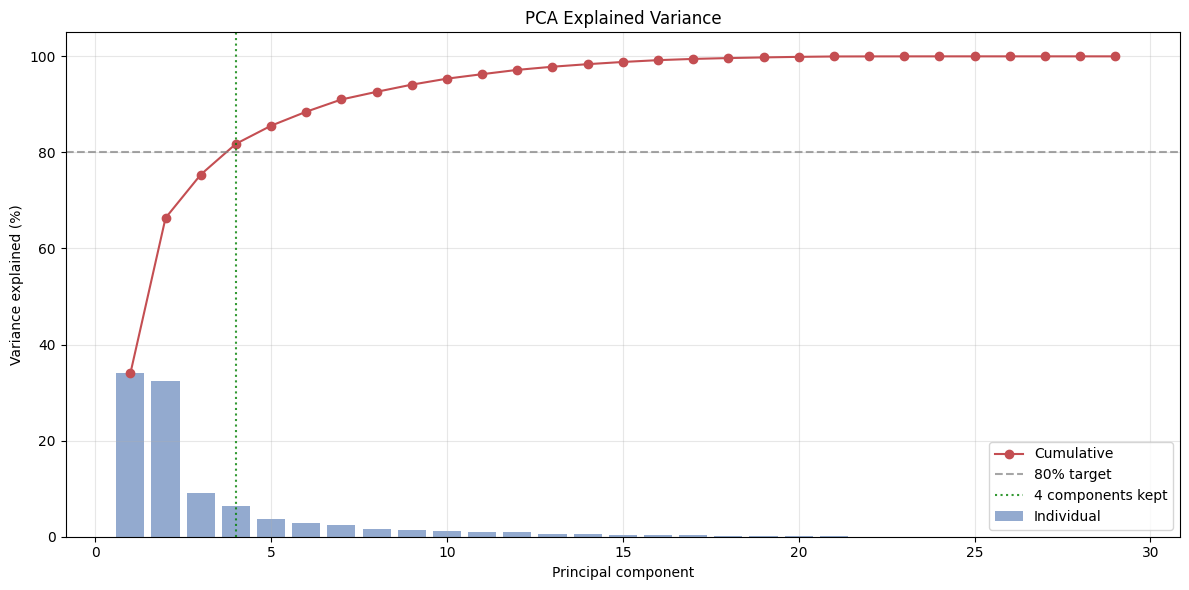

In [4]:
sm = train_signal_model(df, model=MODEL, threshold=THRESHOLD)
kept = sm.pca.n_components
print(f"Kept {kept} components — "
      f"{sm.pca.explained_variance_ratio[:kept].sum()*100:.1f}% variance")
fig = plot_pca_variance(sm.pca); plt.show()

## 4 · ML Model & Signal

Target = **next-day return > 0**. Signal = **Long** if P(up) > 0.60, else **Flat**.

Model: gradient_boosting
Test window: 2025-01-27 -> 2026-07-07 (362 days)
LONG on 103/362 test days


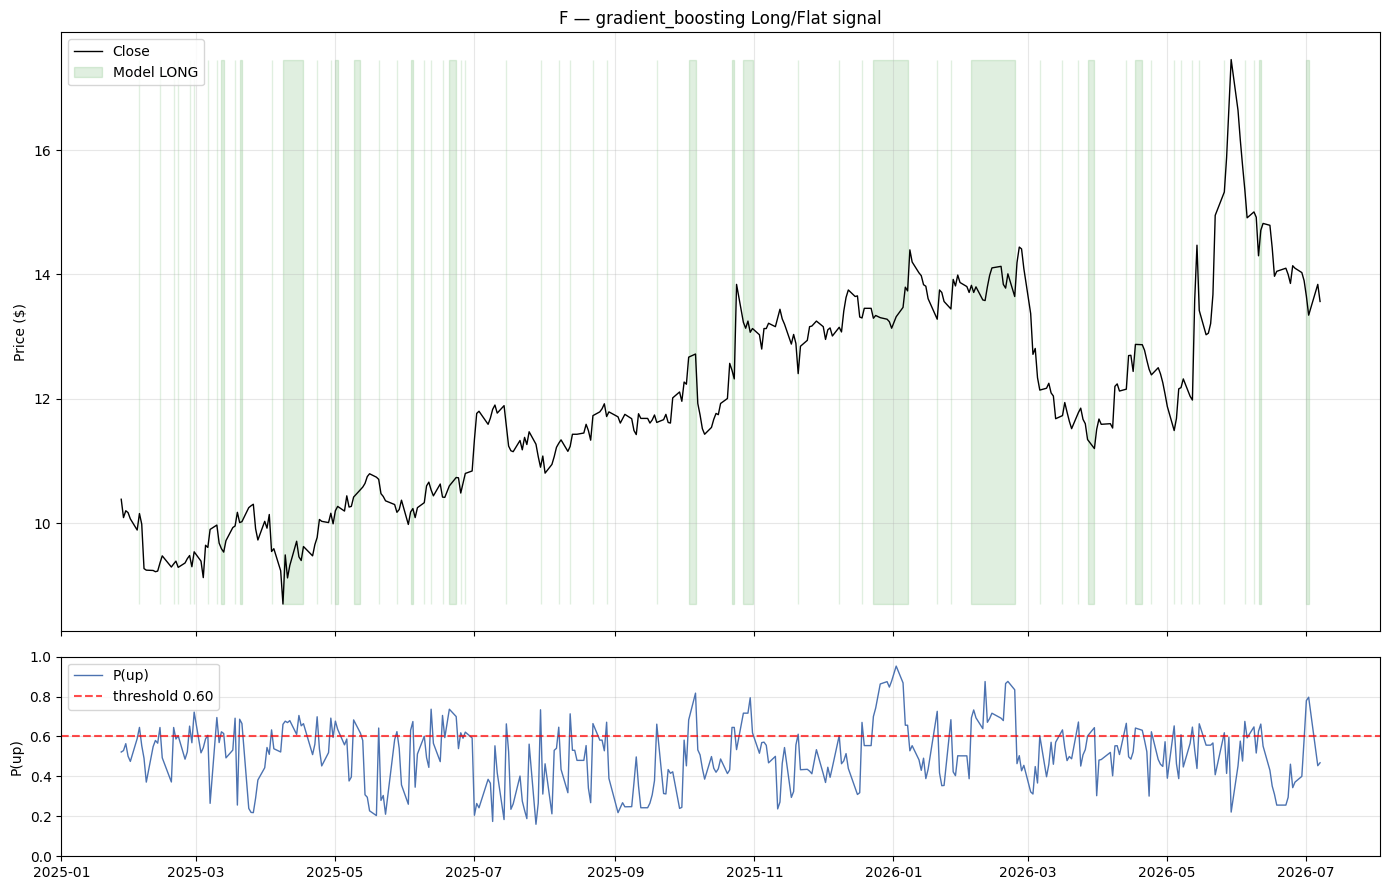

In [5]:
print(f"Model: {sm.name}")
print(f"Test window: {sm.test_index[0].date()} -> {sm.test_index[-1].date()} "
      f"({len(sm.test_index)} days)")
print(f"LONG on {int(sm.signal.sum())}/{len(sm.signal)} test days")
df_test = sm.test_frame()
fig = plot_signal(df_test, sm.proba, sm.signal, sm.threshold,
                  f"{TICKER} — {MODEL} Long/Flat signal"); plt.show()

## 5 · Backtest — ML Signal vs Buy & Hold

$100k, long-only, no leverage, no shorting. Positions act on the next bar.

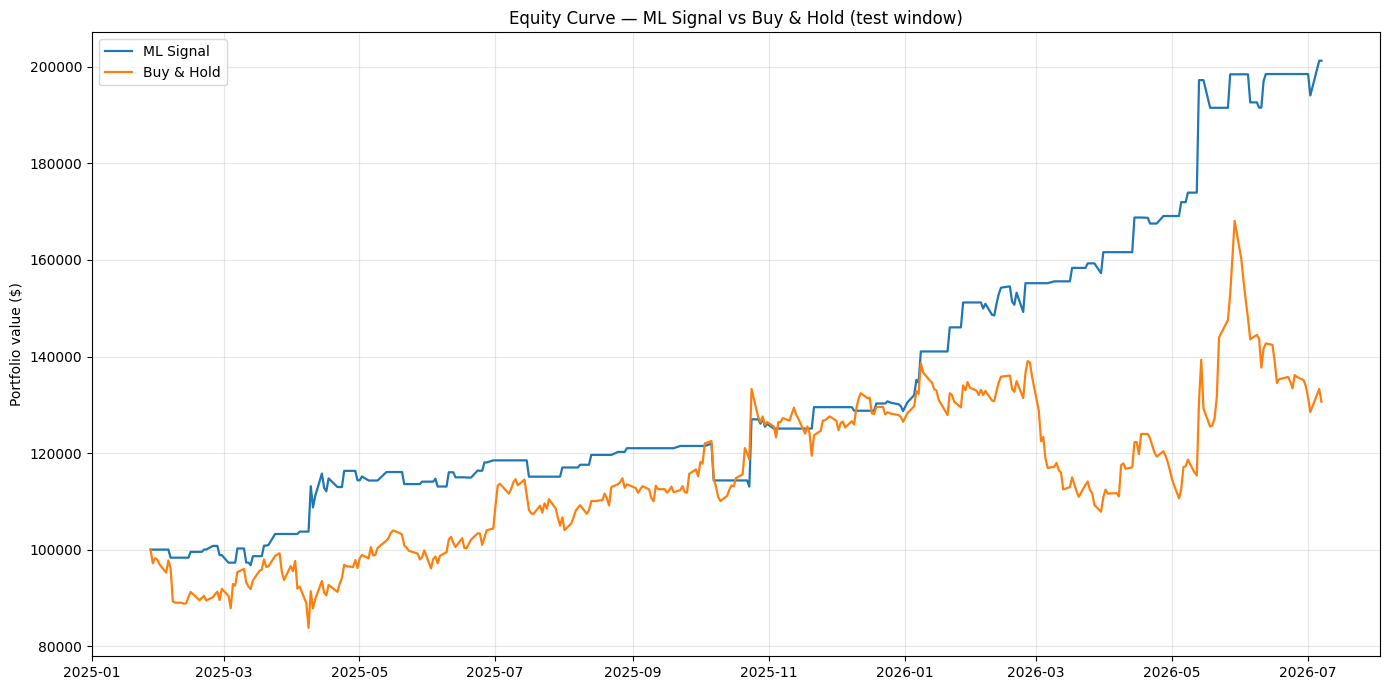

In [6]:
ml = run_backtest(df_test, sm.signal, initial_capital=100_000)
bh = run_backtest(df_test, pd.Series(1, index=df_test.index), initial_capital=100_000)
results = {"ML Signal": ml, "Buy & Hold": bh}
fig = plot_equity_curves(results); plt.show()

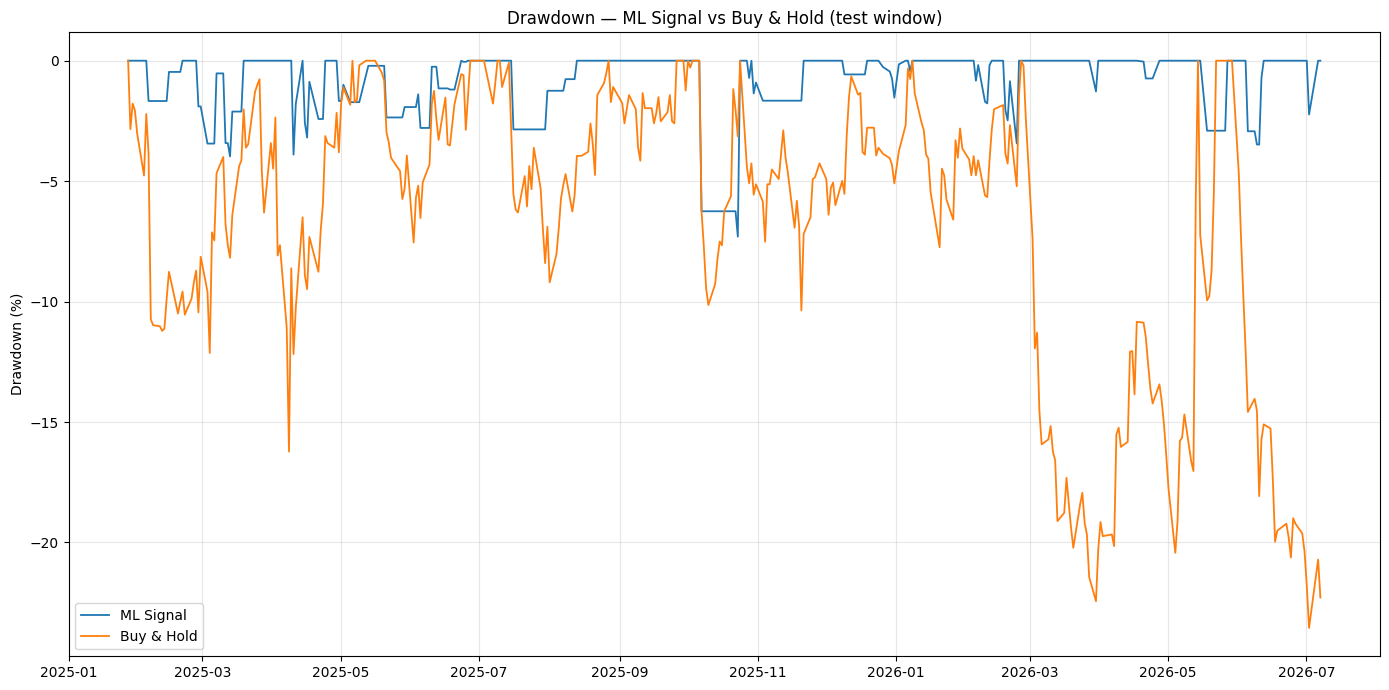

In [7]:
fig = plot_drawdowns(results); plt.show()

## 6 · Performance Metrics

Total Return, CAGR, Volatility, Sharpe, Sortino, Max Drawdown, Win Rate.

In [8]:
metrics_table(results)

,Total Return,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Win Rate,Trades
ML Signal,101.29%,62.74%,23.55%,2.18,2.59,-7.30%,55.93%,59
Buy & Hold,30.62%,20.44%,37.03%,0.68,1.18,-23.55%,100.00%,1


## 7 · Paper Trading Demo

Run from a terminal (submits a **paper** order to Alpaca):

```bash
python paper_trade.py --ticker AAPL --qty 5           # follow the model
python paper_trade.py --ticker AAPL --qty 5 --force buy  # guarantee a demo trade
```

The script fetches the latest data, rebuilds features, applies PCA, generates
the ML signal, and submits a **BUY** (Long) or **SELL** (Flat) order to the
Alpaca paper endpoint. See the README for the dashboard screenshot + logs.

> ⚠️ **PAPER TRADING ONLY — no real money is used.**